## 1. Importing Libs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

## 2. Data Loading & Cleaning

In [2]:
titanic = pd.read_csv(r'C:\Users\ahmed\Desktop\Titanic-Dataset.csv')
titanic = titanic.dropna(subset = ['Age', 'Embarked'])
titanic = titanic.drop(['Name', 'Ticket', 'Cabin', 'PassengerId'], axis = 1)
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].mean())
print(titanic.shape)
print(titanic.isna().sum())

(712, 8)
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


## 3. Feature Encoding

In [3]:
dummies = pd.get_dummies(titanic[['Sex','Embarked']], drop_first = True)
titanic = pd.concat([titanic, dummies], axis=1)
titanic = titanic.drop(['Sex', 'Embarked'], axis = 1)
titanic.head()
titanic.dtypes

Survived        int64
Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_male         bool
Embarked_Q       bool
Embarked_S       bool
dtype: object

## 4. train_test_split

In [4]:
x = titanic.drop('Survived', axis = 1)
y = titanic['Survived']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42)

## 5. Models

### 1. KNN (Tuned)

In [5]:
params_knn= {'n_neighbors': np.arange(1,12)}

knn = KNeighborsClassifier()
kf = KFold(n_splits= 5, random_state=42 , shuffle= True)

knn_grid = GridSearchCV(knn, params_knn, cv = kf)
knn_grid.fit(x_train, y_train)
y_pred_knn = knn_grid.predict(x_test)

best_param_knn = knn_grid.best_params_['n_neighbors']
print(knn_grid.best_params_)
print(knn_grid.best_score_)

{'n_neighbors': 11}
0.7064896755162241


### 2. Logistic Regression

In [6]:
logreg = LogisticRegression(max_iter= 1000)
logreg.fit(x_train, y_train)
y_pred_logreg = logreg.predict(x_test)

### 3. Random Forest (Tuned)

In [7]:
params_rf = {'n_estimators': [50, 100, 200, 300]}

rf = RandomForestClassifier(random_state= 42)
rf_grid = GridSearchCV(rf, param_grid= params_rf, cv= kf)
rf_grid.fit(x_train, y_train)
y_pred_rf = rf_grid.predict(x_test)

best_param_rf = rf_grid.best_params_['n_estimators']
print(rf_grid.best_params_)
print(rf_grid.best_score_)

{'n_estimators': 50}
0.7995652848936501


### 4. XGBoost (Tuned)

In [8]:
params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7]
}
xgb_model = xgb.XGBClassifier(objective= 'binary:logistic')
xgb_grid = GridSearchCV(xgb_model, param_grid= params, cv= kf, scoring= 'accuracy')
xgb_grid.fit(x_train, y_train)

print(xgb_grid.best_params_)
print(xgb_grid.best_score_)
xgb_pred = xgb_grid.predict(x_test)
print(xgb_grid.score(x_test, y_test))

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
0.8224188790560472
0.7902097902097902


## 6. Pipeline KNN

In [9]:
imputer = SimpleImputer()
scaler = StandardScaler()
knn = KNeighborsClassifier(n_neighbors= best_param_knn)

steps = [('imp_mean', imputer),
         ('scaler', scaler),
         ('knn', knn)]

pipeline = Pipeline(steps)
pipeline.fit(x_train, y_train)
y_pred_pipeline = pipeline.predict(x_test)
print(f'Pipeline accuracy: {pipeline.score(x_test, y_test)}')

Pipeline accuracy: 0.7972027972027972


## 7. Model Results

| Model               | Accuracy | F1    | Precision | Recall |
|---------------------|----------|-------|-----------|--------|
| Logistic Regression | 79.7%    | 0.739 | 0.854     | 0.651  |
| KNN (k=11, tuned)   | 64.3%    | 0.592 | 0.597     | 0.587  |
| Random Forest       | 79.0%    | 0.737 | 0.762     | 0.714|
| XGBoost (tuned)     | 79.0%    | 0.746 | 0.800     | 0.698  |
| Pipeline KNN        | 80.4%    | 0.75  | 0.80      | 0.79   |

**Best model: Pipeline KNN — 80.4% accuracy**

Key observations:
- Logistic Regression outperforms raw KNN significantly (79.7% vs 64.3%)
- Random Forest and XGBoost despite being more complex models, 
  didn't beat Logistic Regression on this dataset

In [10]:
print('LogisticRegression:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_logreg)}')
print(f'F1: {f1_score(y_test, y_pred_logreg)}')
print(f'Precision: {precision_score(y_test, y_pred_logreg)}')
print(f'Recall: {recall_score(y_test, y_pred_logreg)}')
print('------------------------------')
print('KNN:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_knn)}')
print(f'F1: {f1_score(y_test, y_pred_knn)}')
print(f'Precision: {precision_score(y_test, y_pred_knn)}')
print(f'Recall: {recall_score(y_test, y_pred_knn)}')
print('------------------------------')
print('RF:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf)}')
print(f'F1: {f1_score(y_test, y_pred_rf)}')
print(f'Precision: {precision_score(y_test, y_pred_rf)}')
print(f'Recall: {recall_score(y_test, y_pred_rf)}')
print('------------------------------')
print('XGBoost')
print(f'Accuracy: {accuracy_score(y_test, xgb_pred)}')
print(f'F1: {f1_score(y_test, xgb_pred)}')
print(f'Precision: {precision_score(y_test, xgb_pred)}')
print(f'Recall: {recall_score(y_test, xgb_pred)}')

LogisticRegression:
Accuracy: 0.7972027972027972
F1: 0.7387387387387387
Precision: 0.8541666666666666
Recall: 0.6507936507936508
------------------------------
KNN:
Accuracy: 0.6433566433566433
F1: 0.592
Precision: 0.5967741935483871
Recall: 0.5873015873015873
------------------------------
RF:
Accuracy: 0.7762237762237763
F1: 0.7377049180327869
Precision: 0.7627118644067796
Recall: 0.7142857142857143
------------------------------
XGBoost
Accuracy: 0.7902097902097902
F1: 0.7457627118644068
Precision: 0.8
Recall: 0.6984126984126984


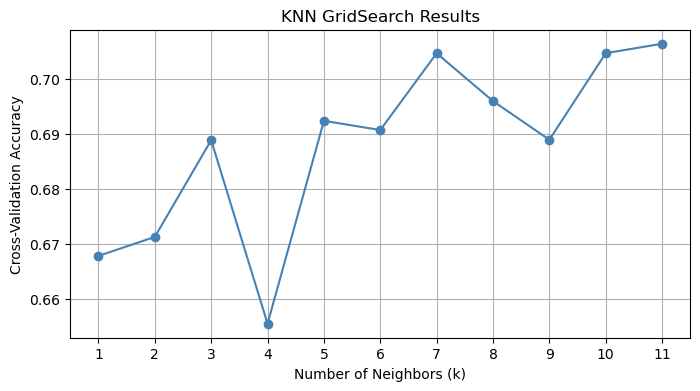

In [11]:
results = knn_grid.cv_results_
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, 12), results['mean_test_score'], marker='o', color='steelblue')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validation Accuracy')
plt.title('KNN GridSearch Results')
plt.xticks(np.arange(1, 12))
plt.grid(True)
plt.show()

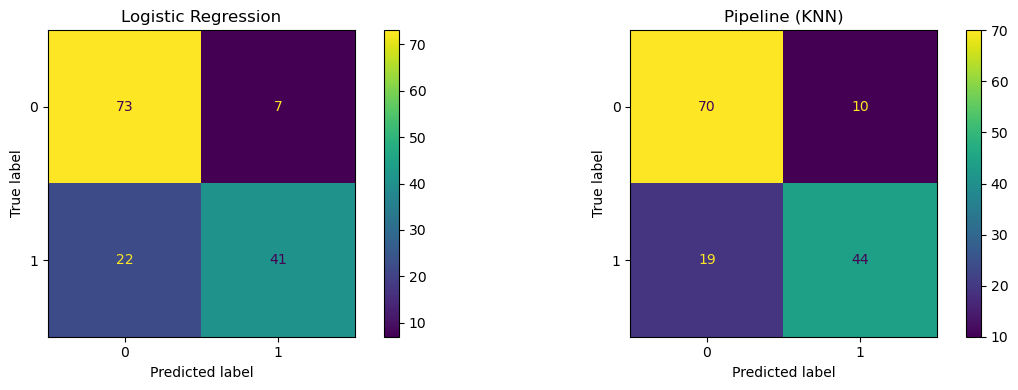

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_logreg, ax=axes[0])
axes[0].set_title('Logistic Regression')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_pipeline, ax=axes[1])
axes[1].set_title('Pipeline (KNN)')
plt.tight_layout()
plt.show()

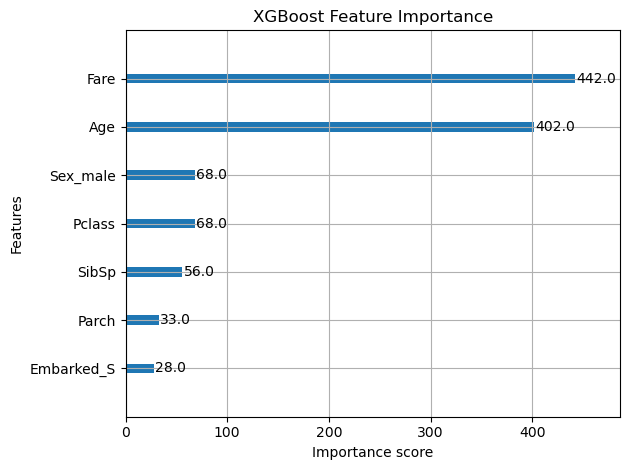

In [13]:
xgb.plot_importance(xgb_grid.best_estimator_)
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()